# Colibri Night Light-Curve Explorer

Interactively browse a whole night of stitched light curves for one telescope.

This notebook:
1. points the package at your data (env vars),
2. builds (and caches) a `NightCatalog`,
3. optionally attaches Gaia magnitudes,
4. launches an interactive explorer (`ipywidgets`), and
5. shows static-plot examples that work even **without** `ipywidgets`.

The interactive widget layer is optional:
```
pip install -r ../../../requirements-notebook.txt
```
If `ipywidgets` is absent, `explore(cat)` returns a plain static plotter instead.

## 1. Point at the data

Pick **one** of the following ways to tell the package where the archive lives.
The package resolves paths in this precedence: explicit args > `COLIBRI_ARCHIVE_ROOT` > sim layout > `D:/ColibriArchive`.

In [13]:
%matplotlib inline
from IPython.display import display
import os, sys

# Make the package importable when running from notebooks/ inside the repo.
# notebooks/ -> lightcurve_analysis/ -> ColibriPipeline/
_here = os.path.abspath(os.getcwd())
for _p in (_here, os.path.dirname(_here), os.path.dirname(os.path.dirname(_here))):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# --- Option A: analysis box — point straight at a downloaded archive folder.
# A folder that directly contains <YYYY-MM-DD>/ night dirs.
# os.environ['COLIBRI_ARCHIVE_ROOT'] = '/data/colibri/green_archive'

# --- Option B: simulated tree (default for this notebook).
os.environ['COLIBRI_ENV'] = 'sim'
os.environ['COLIBRI_SIM_ROOT'] = '/home/agirmen/research_data/ColibriPipelineSimulatedDirs'

TELESCOPE = 'GREENBIRD'
OBSDATE = '2025-08-30'
print('telescope', TELESCOPE, 'date', OBSDATE)

telescope GREENBIRD date 2025-08-30


## 2. Build (or load cached) the night catalog

First run builds and caches; subsequent runs load the cache unless `rebuild=True`.

In [14]:
from lightcurve_analysis import build_night_catalog
from lightcurve_analysis import plotting as P

cat = build_night_catalog(TELESCOPE, OBSDATE)
print(f'{len(cat.stars)} stars, {len(cat.time_axis)} time samples, {len(cat.minutes)} minute(s)')

1287 stars, 2399 time samples, 1 minute(s)


## 3. (Optional) Attach Gaia magnitudes

Queries Vizier once per night (cache-gated). Needs network + WCS in the pos files; on failure `gmag` stays NaN and everything else still works.

In [15]:
from lightcurve_analysis.gaia import attach_gaia

try:
    cat = attach_gaia(cat, search_radius_deg=0.5)
    print('gmag matched for', int(cat.stars['gmag'].notna().sum()), 'stars')
except Exception as exc:
    print('attach_gaia skipped (offline?):', type(exc).__name__, exc)

[gaia] loaded cached Gaia photometry from /home/agirmen/research_data/ColibriPipelineSimulatedDirs/Green/ColibriArchive/2025-08-30/lightcurve_cache/GREENBIRD_2025-08-30_gaia.parquet (631 stars with gmag).
gmag matched for 631 stars


## 4. Inspect and filter the star table

In [16]:
cat.stars.head()

,star_id,ra_deg,dec_deg,x,y,n_minutes,n_valid_frames,median_flux,snr,gmag,bp_rp,field
0,0,273.902479,-19.312132,791.025341,11.293980,1,2399,-1555.839966,-3.106178,NaN,NaN,field0
1,1,273.434769,-19.310619,1456.755516,10.944164,1,2399,-919.679993,-1.736798,NaN,NaN,field0
2,2,273.135913,-19.307235,1883.955667,11.376362,1,2399,3955.840088,4.410382,NaN,NaN,field0
3,3,273.867833,-19.308526,840.368083,16.779250,1,2399,-1476.479980,-3.186158,NaN,NaN,field0
4,4,274.240078,-19.307517,309.181782,16.666548,1,2399,23625.199219,5.872561,NaN,NaN,field0


In [17]:
# Example filter: brightest, highest-SNR stars.
bright = cat.filter_stars(snr_min=cat.stars['snr'].quantile(0.9))
bright = bright.sort_values('snr', ascending=False)
bright.head(10)

,star_id,ra_deg,dec_deg,x,y,n_minutes,n_valid_frames,median_flux,snr,gmag,bp_rp,field
380,380,274.123134,-18.932908,478.850602,584.228427,1,2399,12877.440430,9.677483,10.5134,0.2694,field0
290,290,274.365339,-19.001789,131.864922,479.286822,1,2399,9856.639648,9.443999,NaN,NaN,field0
1196,1196,273.249526,-18.118156,1730.810508,1806.845474,1,2399,11066.240234,8.899422,NaN,NaN,field0
508,508,274.371579,-18.811568,123.574659,766.147899,1,2399,11240.959961,8.804605,NaN,NaN,field0
1236,1236,273.566535,-18.066162,1276.360669,1886.078733,1,2399,10674.559570,8.781241,NaN,NaN,field0
193,193,274.166535,-19.097270,416.029642,336.196973,1,2399,12178.559570,8.780165,NaN,NaN,field0
342,342,274.324287,-18.961123,190.995729,540.941960,1,2399,11509.120117,8.676895,NaN,NaN,field0
626,626,274.264416,-18.716913,277.482514,908.831833,1,2399,8734.080078,8.565512,NaN,NaN,field0
258,258,274.202329,-19.031109,365.273804,435.958757,1,2399,11546.240234,8.548457,NaN,NaN,field0
475,475,274.284300,-18.841050,248.761192,722.057347,1,2399,11386.879883,8.530622,NaN,NaN,field0


## 5. Interactive explorer

If `ipywidgets` is installed you get sliders + a star selector + raw/diff toggle.
Otherwise `explore(cat)` prints a notice and returns a static plotter you can call directly.

In [ ]:
from lightcurve_analysis.widgets import explore

plotter = explore(cat)  # widget UI, or a static plotter if ipywidgets is absent

In [19]:
# When ipywidgets is ABSENT, `plotter` is a callable — you can call it like:
#   fig = plotter(int(bright.iloc[0]['star_id']), kind='both', bin_seconds=1.0)
#   display(fig)
#
# When ipywidgets IS present, `plotter` is the VBox widget already displayed above.
if callable(plotter):
    print("ipywidgets absent — use plotter(star_id, kind='both', bin_seconds=1.0) to render a figure.")
else:
    print("Interactive widget is active above.")


Interactive widget is active above.


## 6. Static-plot examples (no widgets required)

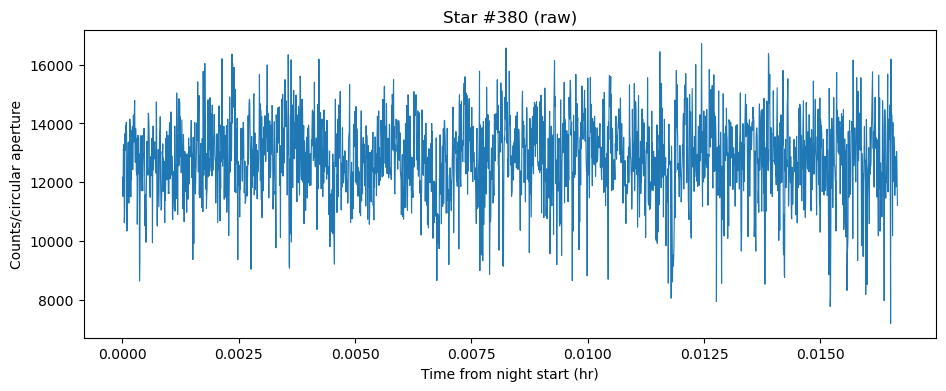

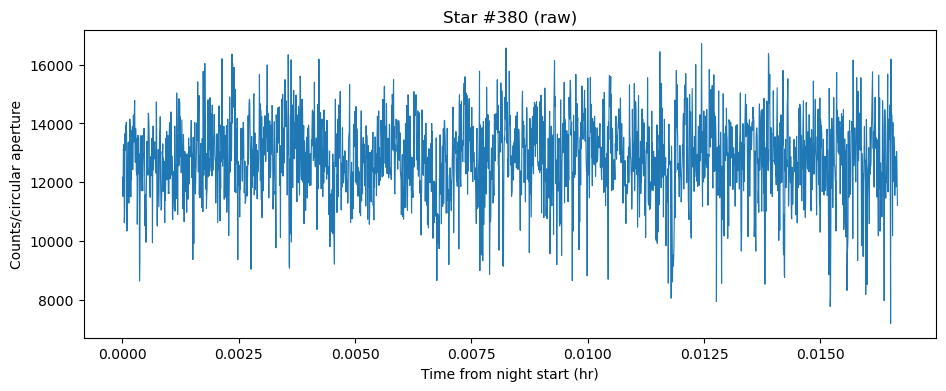

In [20]:
sid = int(bright.iloc[0]['star_id'])

# Single raw light curve.
lc = cat.get_raw_lightcurve(sid)
fig, ax = P.plot_single(lc, title=f'Star #{sid} (raw)')
fig


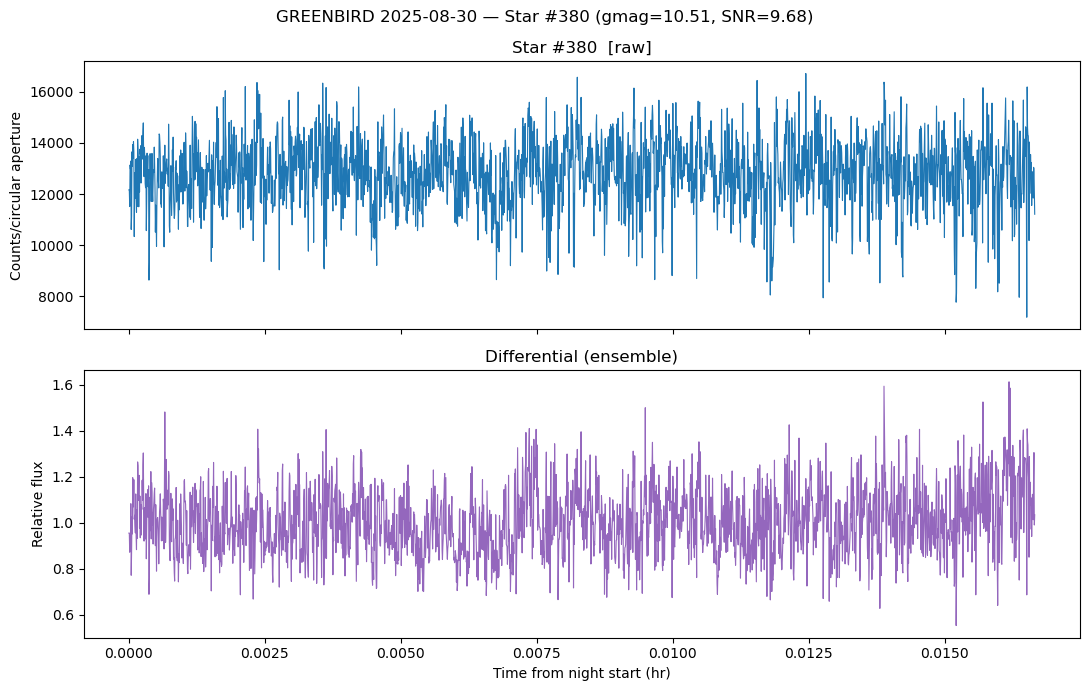

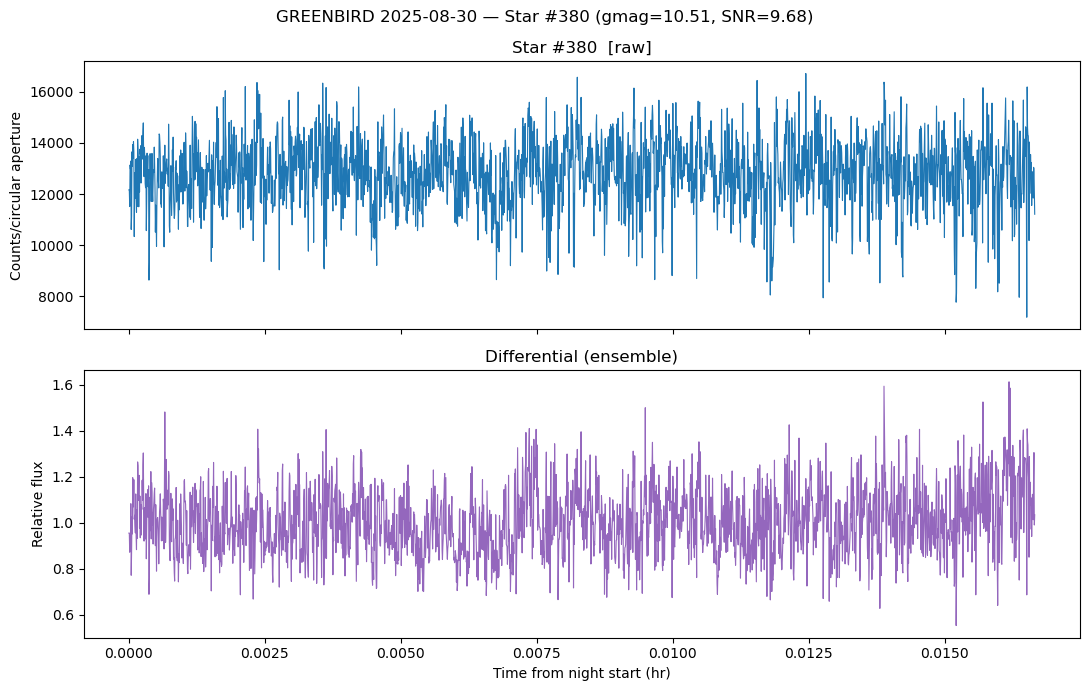

In [21]:
# Stacked raw vs. ensemble differential.
fig = P.plot_raw_vs_diff(cat, sid, comp_rad_pix=150.0)
fig

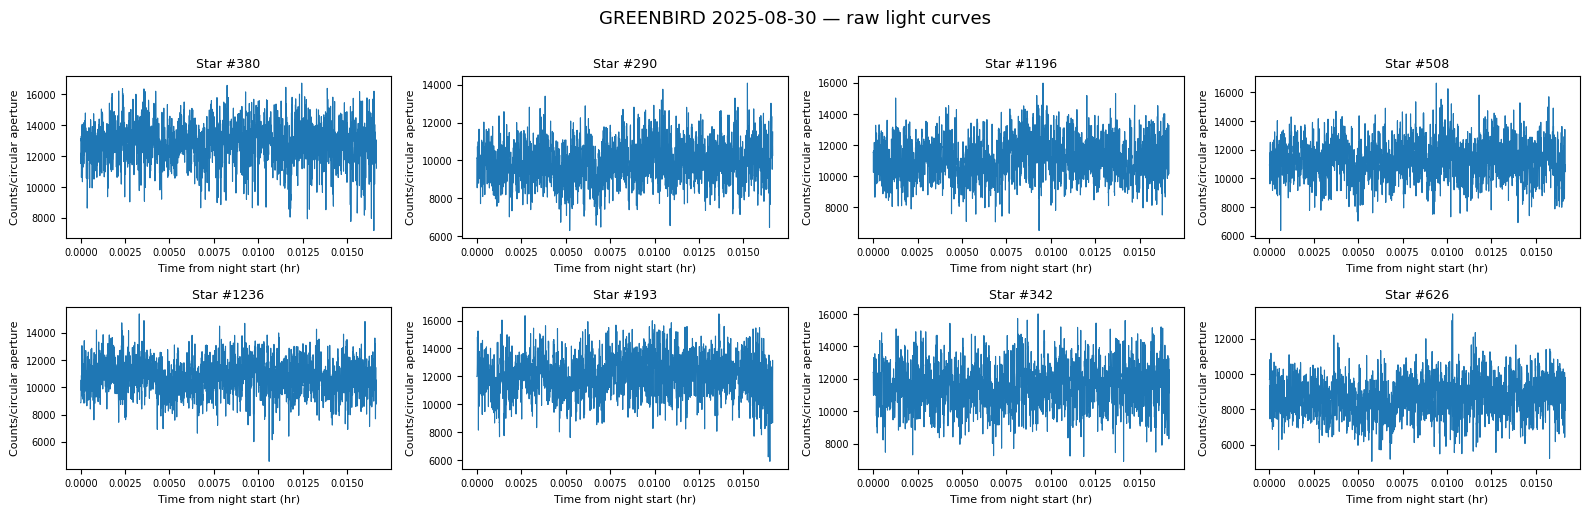

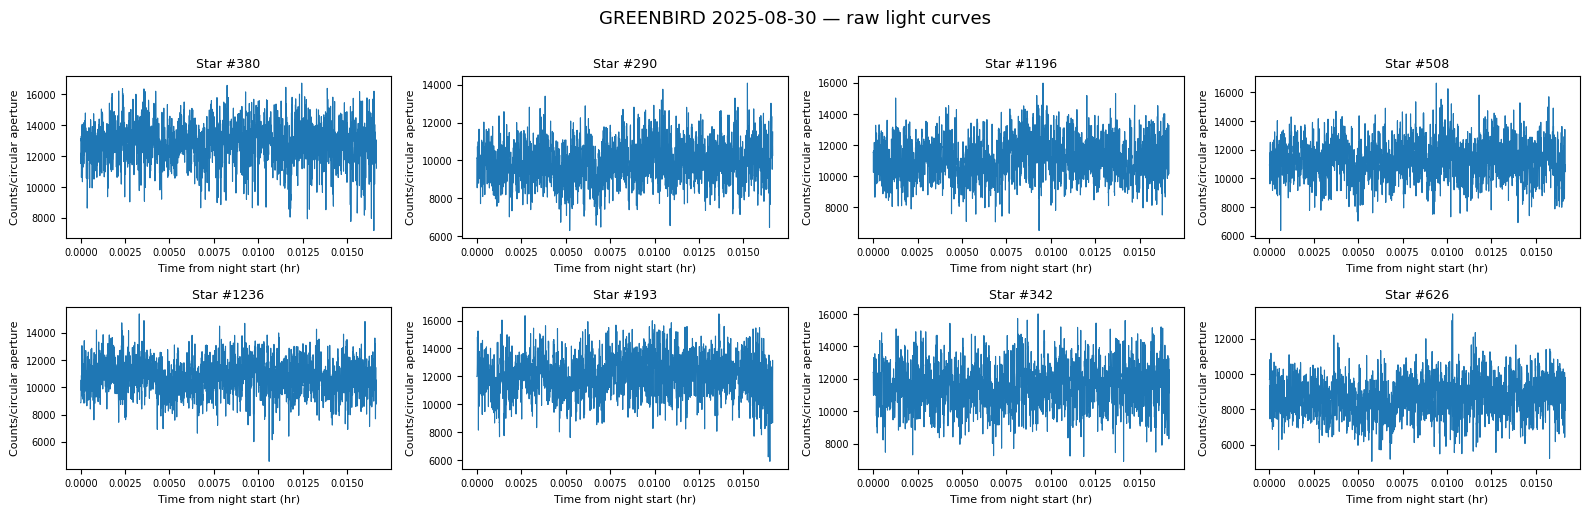

In [22]:
# Grid of the top several stars.
ids = [int(s) for s in bright['star_id'].head(8)]
fig = P.plot_multi_grid(cat, ids, kind='raw', ncols=4)
fig